In [58]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import plotly.express as px

In [59]:
data_merged = pd.read_csv("../data/merged.csv")
data_merged.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,absences_mat,G1_mat,G2_mat,G3_mat,failures_por,paid_por,absences_por,G1_por,G2_por,G3_por
0,GP,F,15,R,GT3,T,1,1,at_home,other,...,2.0,7.0,10.0,10.0,0.0,yes,4.0,13.0,13.0,13.0
1,GP,F,15,R,GT3,T,1,1,other,other,...,NaN,NaN,NaN,NaN,1.0,no,2.0,8.0,9.0,9.0
2,GP,F,15,R,GT3,T,1,1,other,other,...,2.0,8.0,6.0,5.0,0.0,no,2.0,13.0,11.0,11.0
3,GP,F,15,R,GT3,T,2,2,at_home,other,...,8.0,14.0,13.0,13.0,0.0,no,8.0,14.0,13.0,12.0
4,GP,F,15,R,GT3,T,2,4,services,health,...,2.0,10.0,9.0,8.0,0.0,no,2.0,10.0,11.0,10.0


In [60]:
data_numeric = data_merged

In [61]:
data = data_merged.copy().select_dtypes(include='number')
data = data.dropna()

In [62]:
data.head()

,age,Medu,Fedu,traveltime,studytime,failures_mat,famrel,freetime,goout,Dalc,...,health,absences_mat,G1_mat,G2_mat,G3_mat,failures_por,absences_por,G1_por,G2_por,G3_por
0,15,1,1,2,4,1.0,3,1,2,1,...,1,2.0,7.0,10.0,10.0,0.0,4.0,13.0,13.0,13.0
2,15,1,1,1,2,2.0,3,3,4,2,...,5,2.0,8.0,6.0,5.0,0.0,2.0,13.0,11.0,11.0
3,15,2,2,1,1,0.0,4,3,1,1,...,2,8.0,14.0,13.0,13.0,0.0,8.0,14.0,13.0,12.0
4,15,2,4,1,3,0.0,4,3,2,1,...,5,2.0,10.0,9.0,8.0,0.0,2.0,10.0,11.0,10.0
5,15,3,3,2,3,2.0,4,2,1,2,...,3,8.0,10.0,10.0,10.0,0.0,2.0,13.0,13.0,13.0


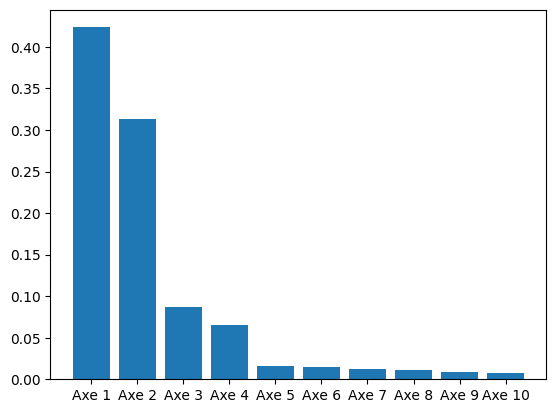

array([0.42360226, 0.73671589, 0.82415149, 0.88897057, 0.9053877 ,
       0.92005586, 0.93253674, 0.94392863, 0.95302597, 0.9610524 ])

In [63]:
cls = PCA(n_components=10) 
pcs = cls.fit_transform(data) 
cls.components_
plt.bar([f"Axe {i+1}" for i in range(10)], cls.explained_variance_ratio_) 
plt.show()
np.cumsum(cls.explained_variance_ratio_)

Les composantes ont bien été calculées !


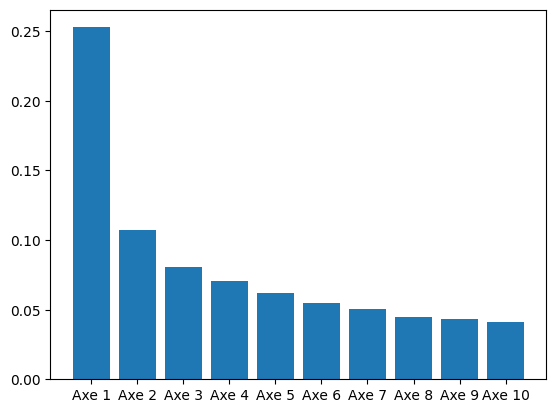

Variance cumulée :
[0.25287524 0.36022747 0.44082352 0.51137905 0.57363106 0.62863279
 0.67935187 0.72422033 0.76718402 0.80837531]


In [64]:
# 1. On standardise les données
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data) 

# 2. On initialise la PCA
cls = PCA(n_components=10) 

# 3. ON ENTRAÎNE LA PCA sur les données standardisées (c'est la ligne qui manquait !)
pcs = cls.fit_transform(data_scaled) 

# Maintenant ça marche ! La PCA a calculé ses composantes
print("Les composantes ont bien été calculées !")
# cls.components_  # (Vous pouvez décommenter si vous voulez afficher la grosse matrice)

# 4. Affichage de la variance
plt.bar([f"Axe {i+1}" for i in range(10)], cls.explained_variance_ratio_) 
plt.show()

print("Variance cumulée :")
print(np.cumsum(cls.explained_variance_ratio_))

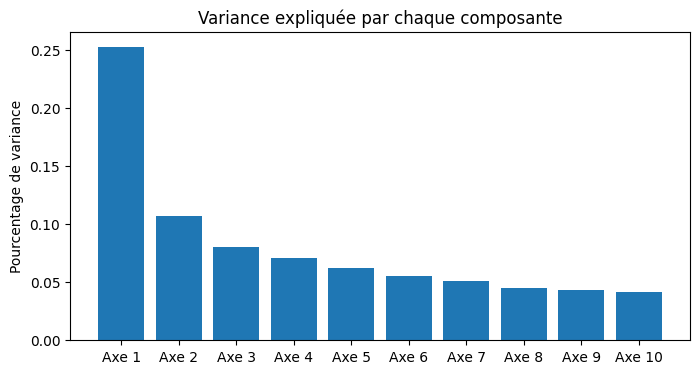

Variance cumulée :
[0.25287524 0.36022747 0.44082352 0.51137905 0.57363106 0.62863279
 0.67935187 0.72422033 0.76718402 0.80837531]


In [65]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Standardisation des données (Moyenne = 0, Variance = 1)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# 2. Application de la PCA sur les données standardisées
pca_model = PCA(n_components=10) 
pcs = pca_model.fit_transform(data_scaled) 

# 3. Affichage de la variance expliquée
plt.figure(figsize=(8, 4))
plt.bar([f"Axe {i+1}" for i in range(10)], pca_model.explained_variance_ratio_) 
plt.title("Variance expliquée par chaque composante")
plt.ylabel("Pourcentage de variance")
plt.show()

# Affichage du cumul de variance
print("Variance cumulée :")
print(np.cumsum(pca_model.explained_variance_ratio_))

In [66]:

def add_labels(x, y, labels, ax=None):
    """Ajoute les étiquettes `labels` aux endroits définis par `x` et `y`."""

    if ax is None:
        ax = plt.gca()
    for x, y, label in zip(x, y, labels):
        ax.annotate(
            label, [x, y], xytext=(10, -5), textcoords="offset points",
        )

    return ax

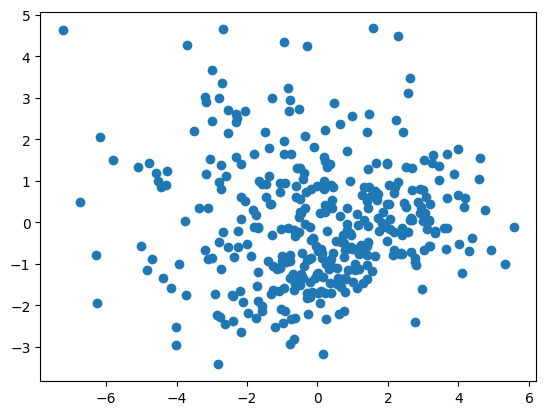

In [67]:
# Représentation dans le premier plan factoriel
plt.scatter(pcs[:, 0], pcs[:, 1]) 
# add_labels(pcs[:, 0], pcs[:, 1], data.index) 
plt.show()

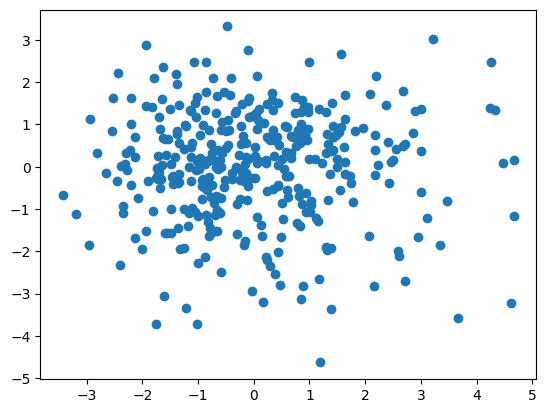

In [68]:
# Représentation dans le deuxième plan factoriel
plt.scatter(pcs[:, 1], pcs[:, 2]) 
plt.show()

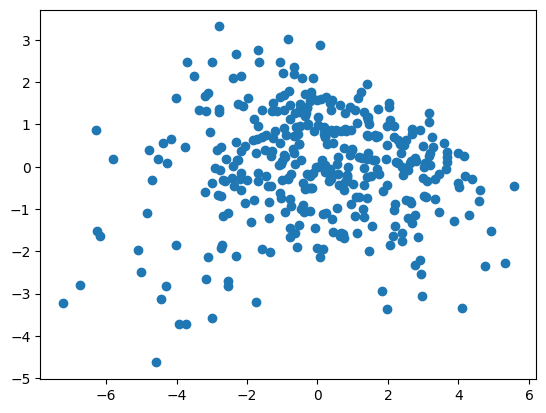

In [69]:
# Représentation dans le troisième plan factoriel
plt.scatter(pcs[:, 0], pcs[:, 2]) 
plt.show()

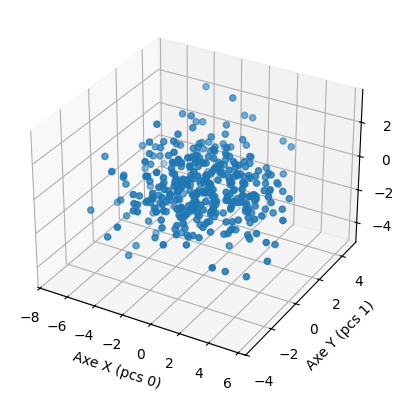

In [70]:
# Visualisation en 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pcs[:, 0], pcs[:, 1], pcs[:, 2])

ax.set_xlabel('Axe X (pcs 0)')
ax.set_ylabel('Axe Y (pcs 1)')
ax.set_zlabel('Axe Z (pcs 2)')

plt.show()

In [71]:
# En version interactive 3d
df = pd.DataFrame(pcs[:, :3], columns=['pcs 0', 'pcs 1', 'pcs 2'])

fig = px.scatter_3d(df, x='pcs 0', y='pcs 1', z='pcs 2')
fig.show()

In [72]:
# Transformation en distances (pour ensuite faire une AFTD dessus)
X = data.copy() 

# standardiser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calcul de la matrice de dissimilarité (avec la distance euclidienne)
matrice_dissimilarite = pairwise_distances(X_scaled, metric='euclidean')
df_distances = pd.DataFrame(matrice_dissimilarite, index=data.index, columns=data.index)

print(df_distances.head())

        0         2         3         4         5         6         7    \
0  0.000000  5.942969  5.650061  5.628687  4.527268  5.792594  6.591871   
2  5.942969  0.000000  6.579748  5.636571  5.156302  6.160522  5.399060   
3  5.650061  6.579748  0.000000  4.877891  5.173035  4.416440  7.421165   
4  5.628687  5.636571  4.877891  0.000000  4.810962  1.744639  4.839787   
5  4.527268  5.156302  5.173035  4.810962  0.000000  4.530542  4.439375   

        8         9         10   ...       650       653       654       656  \
0  4.671652  6.054192  5.384836  ...  9.975221  6.753560  7.835660  7.741999   
2  4.708441  7.271868  6.229541  ...  8.007519  6.346752  6.702235  8.212040   
3  5.197485  5.097474  5.097061  ...  9.183850  5.496485  6.148332  6.463176   
4  3.953358  6.330359  3.017453  ...  8.183039  5.841531  6.160497  7.586769   
5  4.576440  5.270460  5.154597  ...  8.341112  6.151544  5.918494  6.745928   

        658       660       663       664       665       666  
0  5

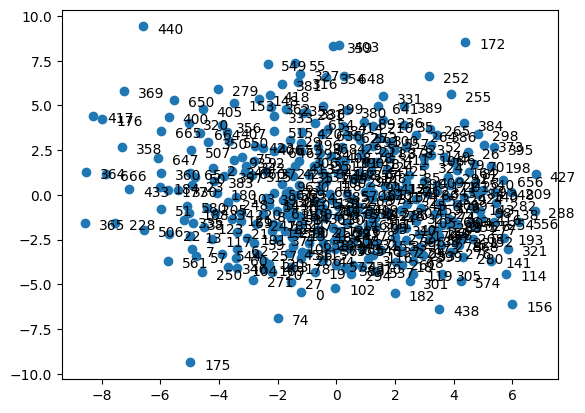

In [73]:
# AFTD
aftd = MDS(n_components=2, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances)
plt.scatter(*dist.T) 
add_labels(dist[:, 0], dist[:, 1], df_distances.index) 
plt.show()

In [74]:
from scipy.spatial.distance import cdist
def plot_Shepard(mds_model, plot=True):
    """Affiche le diagramme de Shepard et retourne un couple contenant les
    dissimilarités originales et les distances apprises par le
    modèle.
    """

    assert isinstance(mds_model, MDS)

    # Inter-distances apprises
    dist = cdist(mds_model.embedding_, mds_model.embedding_)
    idxs = np.tril_indices_from(dist, k=-1)
    dist_mds = dist[idxs]

    # Inter-distances d'origine
    dist = mds_model.dissimilarity_matrix_
    dist_orig = dist[idxs]

    dists = np.column_stack((dist_orig, dist_mds))

    if plot:
        f, ax = plt.subplots()
        range = [dists.min(), dists.max()]
        ax.plot(range, range, 'r--')
        ax.scatter(*dists.T)
        ax.set_xlabel('Dissimilarités')
        ax.set_ylabel('Distances')

    return (*dists.T,)

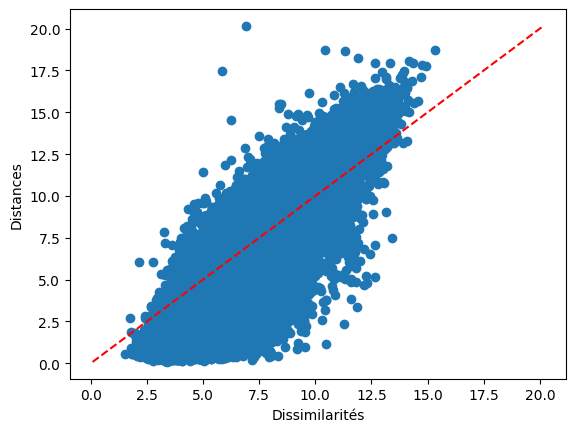

In [75]:
aftd = MDS(n_components=2, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

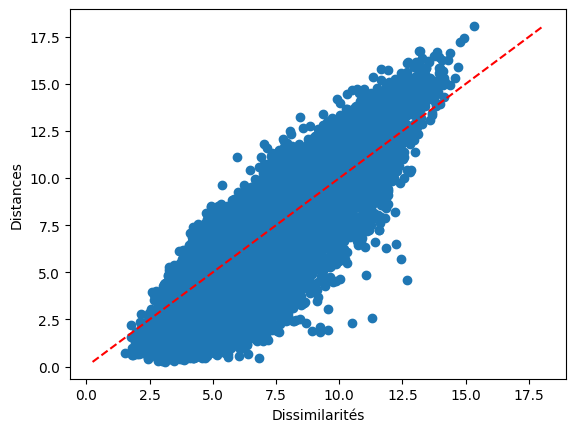

In [76]:
aftd = MDS(n_components=3, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

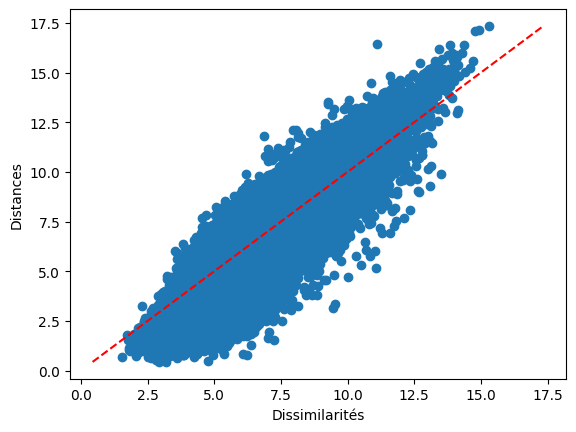

In [77]:
aftd = MDS(n_components=4, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

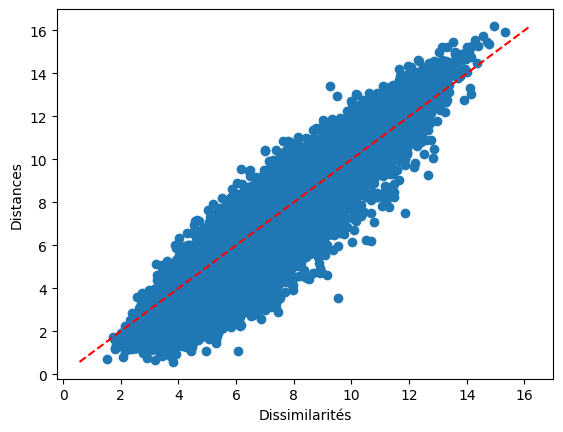

In [78]:
aftd = MDS(n_components=5, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

In [79]:
stress_shepard = aftd.stress_
print(f"Stress théorique = {stress_shepard}")
diss, dist = plot_Shepard(aftd, plot=False)
stress_exp = np.sum((diss - dist)**2)
print(f"Stress théorique = {stress_exp}")

Stress théorique = 43859.734856277915
Stress théorique = 43850.2455534516


In [80]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)

    # Plot the corresponding dendrogram
    default_kwargs = dict(leaf_font_size=10)
    default_kwargs.update(kwargs or {})
        
    dendrogram(linkage_matrix, **default_kwargs)


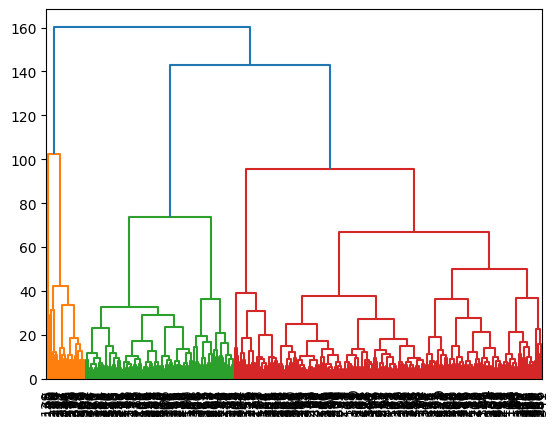

In [81]:
# CAH
cls = AgglomerativeClustering( metric="euclidean", linkage="ward", distance_threshold=0,n_clusters=None)
cls.fit(data)
plot_dendrogram(cls)
plt.show()

In [82]:
# Affiche la liste des variables d'origine
print(data.columns.tolist())

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures_mat', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences_mat', 'G1_mat', 'G2_mat', 'G3_mat', 'failures_por', 'absences_por', 'G1_por', 'G2_por', 'G3_por']


In [83]:
import pandas as pd
from sklearn.decomposition import PCA

# 1. On recalcule la PCA en utilisant un nom de variable dédié (pca_model)
pca_model = PCA(n_components=10)
pcs = pca_model.fit_transform(data)

# 2. On récupère les poids pour les 2 premières composantes
poids = pca_model.components_[:2, :]

# 3. On crée un tableau croisant les composantes et vos variables de départ
df_poids = pd.DataFrame(
    poids.T, 
    columns=['PC1 (Axe X)', 'PC2 (Axe Y)'], 
    index=data.columns
)

print("Poids des variables d'origine sur les composantes principales :")
display(df_poids)

Poids des variables d'origine sur les composantes principales :


,PC1 (Axe X),PC2 (Axe Y)
age,0.022981,-0.018437
Medu,0.003772,0.041815
Fedu,-0.002709,0.030879
traveltime,0.002766,-0.016306
studytime,-0.014759,0.015997
failures_mat,0.014887,-0.039152
famrel,-0.006645,-0.000294
freetime,-0.002742,-0.006331
goout,0.018350,-0.020209
Dalc,0.021547,-0.008962


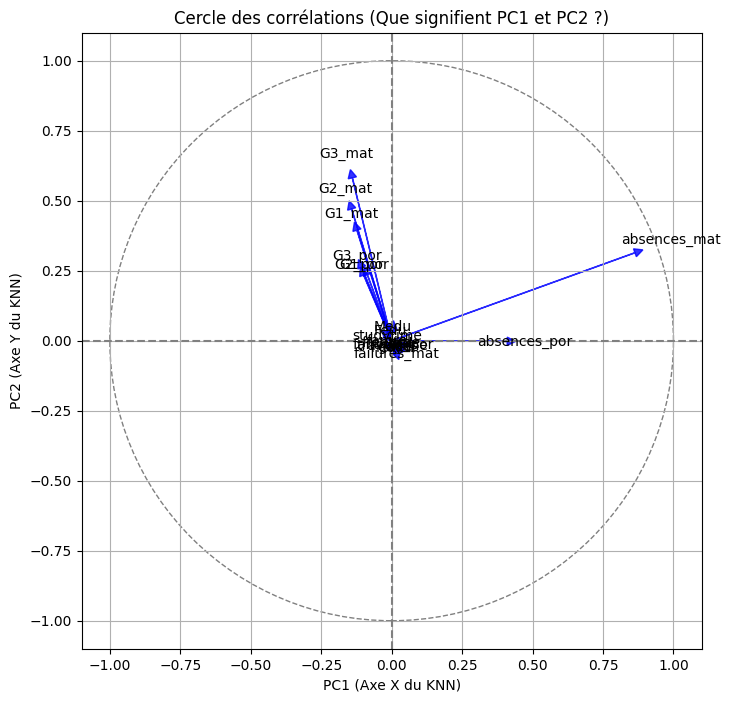

In [84]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

# Tracer les flèches pour chaque variable
for i in range(pca_model.components_.shape[1]):
    ax.arrow(0, 0, pca_model.components_[0, i], pca_model.components_[1, i], 
             head_width=0.03, head_length=0.03, color='blue', alpha=0.8)
    
    # Ajouter le nom de la variable au bout de la flèche
    ax.text(pca_model.components_[0, i] * 1.15, pca_model.components_[1, i] * 1.15, 
            data.columns[i], color='black', ha='center', va='center', fontsize=10)

# Dessiner un cercle de rayon 1
cercle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)

# Mise en forme du graphique
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Cercle des corrélations (Que signifient PC1 et PC2 ?)")
plt.xlabel("PC1 (Axe X du KNN)")
plt.ylabel("PC2 (Axe Y du KNN)")
plt.grid()
plt.show()

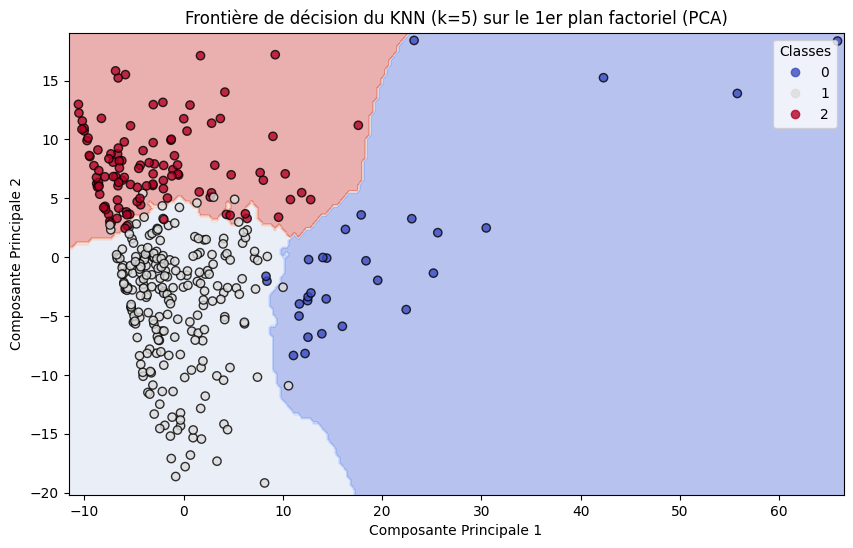

In [94]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraction des 2 premières composantes principales de la PCA (pour la 2D)
# (La variable 'pcs' provient de votre exécution précédente 'pcs = cls.fit_transform(data)')
X_pca = pcs[:, :2]

# --- DÉFINITION DE LA CIBLE (Y) ---
# Vous devez définir les étiquettes de vos données. 
# Exemple 1 : Si vous avez une colonne "classe" dans votre dataframe initial
# y_labels = data_merged['nom_de_la_colonne_cible']

# Exemple 2 : Utiliser les clusters trouvés par votre CAH comme classes
from sklearn.cluster import AgglomerativeClustering
# On suppose 3 clusters pour l'exemple
y_labels = AgglomerativeClustering(n_clusters=3).fit_predict(data)
# ----------------------------------

# Encodage au cas où vos labels seraient sous forme de texte (ex: "A", "B")
le = LabelEncoder()
y = le.fit_transform(y_labels)

# 2. Entraînement du modèle KNN avec k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_pca, y)

# 3. Création du maillage (meshgrid) pour tracer la frontière de décision
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

# On définit la finesse de la grille (pas de h)
h = (x_max - x_min) / 200
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 4. Prédiction des classes pour chaque point de la grille
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Visualisation
plt.figure(figsize=(10, 6))

# Tracé des régions colorées (frontières de décision)
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)

# Tracé des points de données projetés par la PCA
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.8, 
                      cmap=plt.cm.coolwarm, edgecolors='k')

# Ajout de la légende
handles, _ = scatter.legend_elements()
plt.legend(handles, le.classes_, title="Classes")

plt.title("Frontière de décision du KNN (k=5) sur le 1er plan factoriel (PCA)")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.show()

In [88]:
import pandas as pd
from sklearn.decomposition import PCA

# 1. On recalcule la PCA en utilisant un nom de variable dédié (pca_model)
pca_model = PCA(n_components=10)
pcs = pca_model.fit_transform(data)

# 2. On récupère les poids pour les 2 premières composantes
poids = pca_model.components_[2:4, :]

# 3. On crée un tableau croisant les composantes et vos variables de départ
df_poids = pd.DataFrame(
    poids.T, 
    columns=['PC2 (Axe X)', 'PC3 (Axe Y)'], 
    index=data.columns
)

print("Poids des variables d'origine sur les composantes principales :")
display(df_poids)

Poids des variables d'origine sur les composantes principales :


,PC2 (Axe X),PC3 (Axe Y)
age,-0.002004,0.035877
Medu,0.005944,0.023503
Fedu,0.020830,0.012923
traveltime,-0.004031,-0.020504
studytime,-0.005047,0.071391
failures_mat,0.009444,-0.020552
famrel,-0.005347,0.000959
freetime,0.002770,-0.051827
goout,0.019170,-0.021657
Dalc,-0.006179,-0.087800


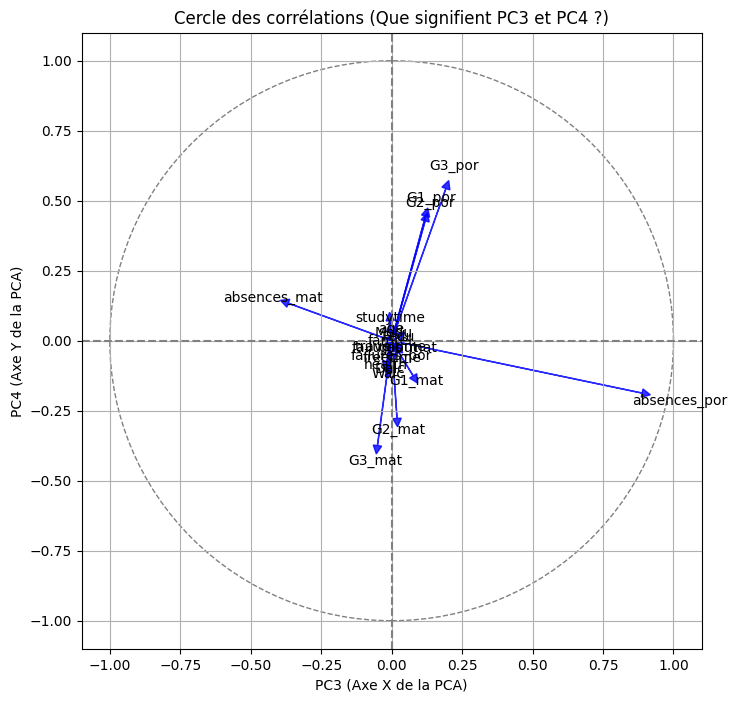

In [90]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

# Tracer les flèches pour chaque variable
for i in range(pca_model.components_.shape[1]):
    ax.arrow(0, 0, pca_model.components_[2, i], pca_model.components_[3, i], 
             head_width=0.03, head_length=0.03, color='blue', alpha=0.8)
    
    # Ajouter le nom de la variable au bout de la flèche
    ax.text(pca_model.components_[2, i] * 1.15, pca_model.components_[3, i] * 1.15, 
            data.columns[i], color='black', ha='center', va='center', fontsize=10)

# Dessiner un cercle de rayon 1
cercle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)

# Mise en forme du graphique
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Cercle des corrélations (Que signifient PC3 et PC4 ?)")
plt.xlabel("PC3 (Axe X de la PCA)")
plt.ylabel("PC4 (Axe Y de la PCA)")
plt.grid()
plt.show()

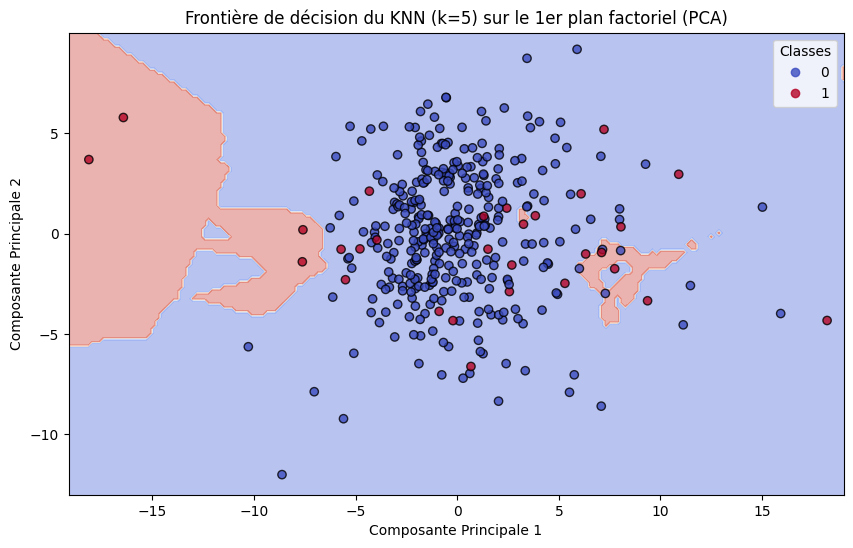

In [92]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraction des 2 premières composantes principales de la PCA (pour la 2D)
# (La variable 'pcs' provient de votre exécution précédente 'pcs = cls.fit_transform(data)')
X_pca = pcs[:, 2:4]

# --- DÉFINITION DE LA CIBLE (Y) ---
# Vous devez définir les étiquettes de vos données. 
# Exemple 1 : Si vous avez une colonne "classe" dans votre dataframe initial
# y_labels = data_merged['nom_de_la_colonne_cible']

# Exemple 2 : Utiliser les clusters trouvés par votre CAH comme classes
from sklearn.cluster import AgglomerativeClustering
# On suppose 3 clusters pour l'exemple
y_labels = AgglomerativeClustering(n_clusters=2).fit_predict(data)
# ----------------------------------

# Encodage au cas où vos labels seraient sous forme de texte (ex: "A", "B")
le = LabelEncoder()
y = le.fit_transform(y_labels)

# 2. Entraînement du modèle KNN avec k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_pca, y)

# 3. Création du maillage (meshgrid) pour tracer la frontière de décision
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

# On définit la finesse de la grille (pas de h)
h = (x_max - x_min) / 200
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 4. Prédiction des classes pour chaque point de la grille
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Visualisation
plt.figure(figsize=(10, 6))

# Tracé des régions colorées (frontières de décision)
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)

# Tracé des points de données projetés par la PCA
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.8, 
                      cmap=plt.cm.coolwarm, edgecolors='k')

# Ajout de la légende
handles, _ = scatter.legend_elements()
plt.legend(handles, le.classes_, title="Classes")

plt.title("Frontière de décision du KNN (k=5) sur le 1er plan factoriel (PCA)")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.show()